<a href="https://colab.research.google.com/github/FurqanAlyy/AI-ML-NIAI/blob/main/EDA_on_Football_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q kagglehub[pandas-datasets]

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("stefanoleone992/fifa-23-complete-player-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fifa-23-complete-player-dataset' dataset.
Path to dataset files: /kaggle/input/fifa-23-complete-player-dataset


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="dark")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_rows", None)

file_path = "/kaggle/input/fifa-23-complete-player-dataset/male_players.csv"

use_cols = [
    "short_name",
    "player_positions",
    "overall",
    "potential",
    "age",
    "preferred_foot",
    "weak_foot",
    "skill_moves",
    "pace",
    "shooting",
    "passing",
    "dribbling",
    "defending",
    "physic",
    "fifa_version"
]

df = pd.read_csv(file_path, usecols=use_cols)

print("Shape:", df.shape)
print(df["fifa_version"].value_counts().sort_index())


Shape: (10003590, 15)
fifa_version
15     962549
16     986175
17    1601431
18    1512360
19    1229986
20    1128336
21    1197628
22    1218451
23     166674
Name: count, dtype: int64


In [6]:
df.head(20)

,fifa_version,short_name,player_positions,overall,potential,age,preferred_foot,weak_foot,skill_moves,pace,shooting,passing,dribbling,defending,physic
0,23,L. Messi,RW,91,91,35,Left,4,4,81.0,89.0,90.0,94.0,34.0,64.0
1,23,K. Benzema,"CF, ST",91,91,34,Right,4,4,80.0,88.0,83.0,87.0,39.0,78.0
2,23,R. Lewandowski,ST,91,91,33,Right,4,4,75.0,91.0,79.0,86.0,44.0,83.0
3,23,K. De Bruyne,"CM, CAM",91,91,31,Right,5,4,74.0,88.0,93.0,87.0,63.0,77.0
4,23,K. Mbappé,"ST, LW",91,95,23,Right,4,5,97.0,89.0,80.0,92.0,36.0,76.0
5,23,T. Courtois,GK,90,91,30,Left,3,1,NaN,NaN,NaN,NaN,NaN,NaN
6,23,M. Salah,RW,90,90,30,Left,3,4,90.0,89.0,82.0,90.0,45.0,75.0
7,23,M. Neuer,GK,89,89,36,Right,4,1,NaN,NaN,NaN,NaN,NaN,NaN
8,23,Neymar Jr,LW,89,89,30,Right,5,5,87.0,83.0,85.0,93.0,37.0,61.0
9,23,Casemiro,CDM,89,89,30,Right,3,2,63.0,73.0,78.0,73.0,88.0,89.0


In [7]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10003590 entries, 0 to 10003589
Data columns (total 15 columns):
 #   Column            Dtype  
---  ------            -----  
 0   fifa_version      int64  
 1   short_name        object 
 2   player_positions  object 
 3   overall           int64  
 4   potential         int64  
 5   age               int64  
 6   preferred_foot    object 
 7   weak_foot         int64  
 8   skill_moves       int64  
 9   pace              float64
 10  shooting          float64
 11  passing           float64
 12  dribbling         float64
 13  defending         float64
 14  physic            float64
dtypes: float64(6), int64(6), object(3)
memory usage: 1.1+ GB


,fifa_version,overall,potential,age,weak_foot,skill_moves,pace,shooting,passing,dribbling,defending,physic
count,1.000359e+07,1.000359e+07,1.000359e+07,1.000359e+07,1.000359e+07,1.000359e+07,8.882478e+06,8.882478e+06,8.882478e+06,8.882478e+06,8.882478e+06,8.882478e+06
mean,1.863230e+01,6.581720e+01,7.080064e+01,2.484595e+01,2.942308e+00,2.331362e+00,6.824552e+01,5.233220e+01,5.705749e+01,6.216787e+01,5.118633e+01,6.487995e+01
std,2.244450e+00,7.029473e+00,6.226342e+00,4.699870e+00,6.626402e-01,7.539601e-01,1.095496e+01,1.393209e+01,1.049882e+01,1.032728e+01,1.671696e+01,9.679165e+00
min,1.500000e+01,3.500000e+01,4.000000e+01,1.500000e+01,1.000000e+00,1.000000e+00,2.100000e+01,1.400000e+01,2.000000e+01,2.200000e+01,1.400000e+01,2.500000e+01
25%,1.700000e+01,6.100000e+01,6.700000e+01,2.100000e+01,3.000000e+00,2.000000e+00,6.200000e+01,4.200000e+01,5.000000e+01,5.600000e+01,3.600000e+01,5.900000e+01
50%,1.800000e+01,6.600000e+01,7.100000e+01,2.400000e+01,3.000000e+00,2.000000e+00,6.900000e+01,5.400000e+01,5.800000e+01,6.300000e+01,5.600000e+01,6.600000e+01
75%,2.100000e+01,7.000000e+01,7.500000e+01,2.800000e+01,3.000000e+00,3.000000e+00,7.600000e+01,6.300000e+01,6.400000e+01,6.900000e+01,6.500000e+01,7.200000e+01
max,2.300000e+01,9.400000e+01,9.800000e+01,5.500000e+01,5.000000e+00,5.000000e+00,9.700000e+01,9.400000e+01,9.300000e+01,9.600000e+01,9.100000e+01,9.200000e+01


In [8]:
df["fifa_version"].value_counts()

,count
fifa_version,
17,1601431
18,1512360
19,1229986
22,1218451
21,1197628
20,1128336
16,986175
15,962549
23,166674


In [9]:
df = df[df["fifa_version"] == 23].copy()
df.drop(columns="fifa_version", inplace=True)



Shape: (166674, 14)


,short_name,player_positions,overall,potential,age,preferred_foot,weak_foot,skill_moves,pace,shooting,passing,dribbling,defending,physic
0,L. Messi,RW,91,91,35,Left,4,4,81.0,89.0,90.0,94.0,34.0,64.0
1,K. Benzema,"CF, ST",91,91,34,Right,4,4,80.0,88.0,83.0,87.0,39.0,78.0
2,R. Lewandowski,ST,91,91,33,Right,4,4,75.0,91.0,79.0,86.0,44.0,83.0
3,K. De Bruyne,"CM, CAM",91,91,31,Right,5,4,74.0,88.0,93.0,87.0,63.0,77.0
4,K. Mbappé,"ST, LW",91,95,23,Right,4,5,97.0,89.0,80.0,92.0,36.0,76.0


In [42]:
print("Shape:", df.shape)
df.head()

Shape: (36050, 16)


,short_name,player_positions,overall,potential,age,preferred_foot,weak_foot,skill_moves,pace,shooting,passing,dribbling,defending,physic,overall_level,main_position
0,L. Messi,RW,91,91,35,Left,4,4,81.0,89.0,90.0,94.0,34.0,64.0,high,RW
1,K. Benzema,"CF, ST",91,91,34,Right,4,4,80.0,88.0,83.0,87.0,39.0,78.0,high,CF
2,R. Lewandowski,ST,91,91,33,Right,4,4,75.0,91.0,79.0,86.0,44.0,83.0,high,ST
3,K. De Bruyne,"CM, CAM",91,91,31,Right,5,4,74.0,88.0,93.0,87.0,63.0,77.0,high,CM
4,K. Mbappé,"ST, LW",91,95,23,Right,4,5,97.0,89.0,80.0,92.0,36.0,76.0,high,ST


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 166674 entries, 0 to 166673
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   short_name        166674 non-null  object 
 1   player_positions  166674 non-null  object 
 2   overall           166674 non-null  int64  
 3   potential         166674 non-null  int64  
 4   age               166674 non-null  int64  
 5   preferred_foot    166674 non-null  object 
 6   weak_foot         166674 non-null  int64  
 7   skill_moves       166674 non-null  int64  
 8   pace              148068 non-null  float64
 9   shooting          148068 non-null  float64
 10  passing           148068 non-null  float64
 11  dribbling         148068 non-null  float64
 12  defending         148068 non-null  float64
 13  physic            148068 non-null  float64
dtypes: float64(6), int64(5), object(3)
memory usage: 19.1+ MB


In [13]:
print(df.isnull().sum())

print(
    f"\nNaN rows={df.isnull().any(axis=1).sum()} "
    f"({df.isnull().any(axis=1).mean()*100:.2f}% of data)"
)

short_name              0
player_positions        0
overall                 0
potential               0
age                     0
preferred_foot          0
weak_foot               0
skill_moves             0
pace                18606
shooting            18606
passing             18606
dribbling           18606
defending           18606
physic              18606
dtype: int64

NaN rows=18606 (11.16% of data)


In [16]:
df.dropna(inplace=True)

print("After dropping rows:", df.shape)

print(df.isnull().sum())

After dropping rows: (148068, 14)
short_name          0
player_positions    0
overall             0
potential           0
age                 0
preferred_foot      0
weak_foot           0
skill_moves         0
pace                0
shooting            0
passing             0
dribbling           0
defending           0
physic              0
dtype: int64


In [18]:
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Duplicate rows: 112018
Shape after removing duplicates: (36050, 14)


In [20]:
df["player_positions"] = df["player_positions"].astype("category")
df["preferred_foot"] = df["preferred_foot"].astype("category")
df["weak_foot"] = df["weak_foot"].astype("category")
df["skill_moves"] = df["skill_moves"].astype("category")

df["short_name"] = df["short_name"].str.strip()

In [43]:
cat_cols = [
    "player_positions",
    "preferred_foot",
    "weak_foot",
    "skill_moves"
]

num_cols = [
    "overall",
    "potential",
    "age",
    "pace",
    "shooting",
    "passing",
    "dribbling",
    "defending",
    "physic"
]


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36050 entries, 0 to 166656
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   short_name        36050 non-null  object  
 1   player_positions  36050 non-null  category
 2   overall           36050 non-null  int64   
 3   potential         36050 non-null  int64   
 4   age               36050 non-null  int64   
 5   preferred_foot    36050 non-null  category
 6   weak_foot         36050 non-null  category
 7   skill_moves       36050 non-null  category
 8   pace              36050 non-null  float64 
 9   shooting          36050 non-null  float64 
 10  passing           36050 non-null  float64 
 11  dribbling         36050 non-null  float64 
 12  defending         36050 non-null  float64 
 13  physic            36050 non-null  float64 
 14  overall_level     36050 non-null  category
 15  main_position     36050 non-null  category
dtypes: category(6), float64(6)

In [23]:
df["overall_level"] = pd.cut(
    df["overall"],
    bins=[0, 60, 75, df["overall"].max() + 1],
    labels=["low", "medium", "high"],
    right=False
)

df[["overall", "overall_level"]].head(10)

,overall,overall_level
0,91,high
1,91,high
2,91,high
3,91,high
4,91,high
6,90,high
8,89,high
9,89,high
11,89,high
12,89,high


In [24]:
df["main_position"] = df["player_positions"].str.split(",").str[0].str.strip()

df["main_position"] = df["main_position"].astype("category")

df[["player_positions", "main_position"]].head(10)

,player_positions,main_position
0,RW,RW
1,"CF, ST",CF
2,ST,ST
3,"CM, CAM",CM
4,"ST, LW",ST
6,RW,RW
8,LW,LW
9,CDM,CDM
11,ST,ST
12,CB,CB


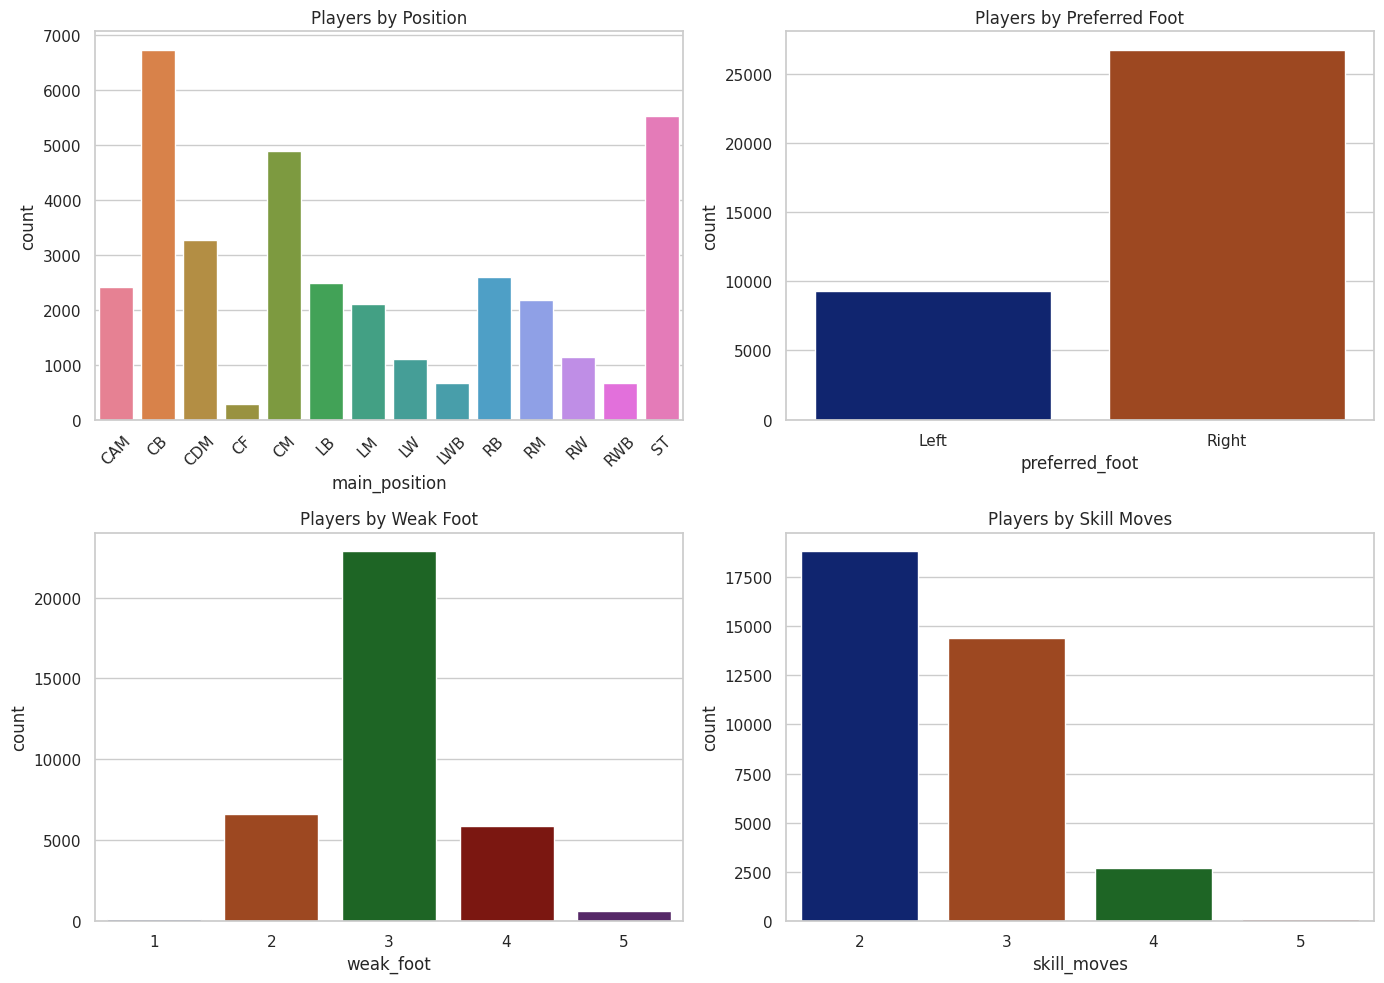

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(
    data=df,
    x="main_position",
    hue="main_position",
    ax=axes[0, 0],
    legend=False
)
axes[0, 0].set_title("Players by Position")
axes[0, 0].tick_params(axis="x", rotation=45)

sns.countplot(
    data=df,
    x="preferred_foot",
    hue="preferred_foot",
    ax=axes[0, 1],
    legend=False
)
axes[0, 1].set_title("Players by Preferred Foot")

sns.countplot(
    data=df,
    x="weak_foot",
    hue="weak_foot",
    ax=axes[1, 0],
    legend=False
)
axes[1, 0].set_title("Players by Weak Foot")

sns.countplot(
    data=df,
    x="skill_moves",
    hue="skill_moves",
    ax=axes[1, 1],
    legend=False
)
axes[1, 1].set_title("Players by Skill Moves")

plt.tight_layout()
plt.show()

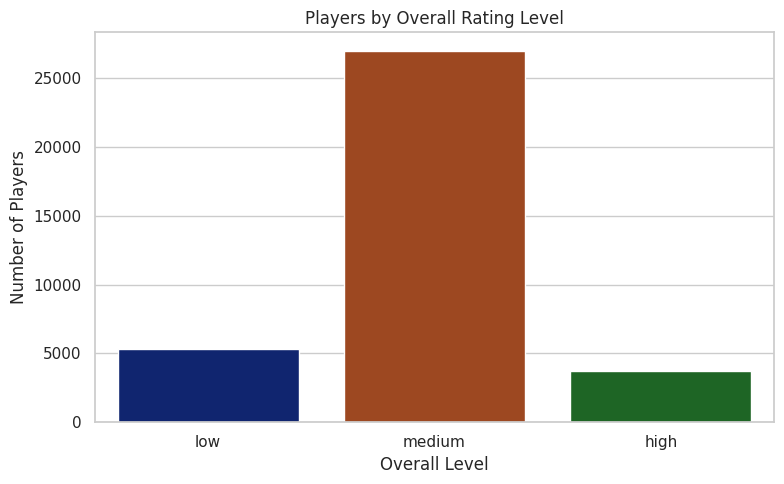

In [32]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="overall_level",
    hue="overall_level",
    legend=False
)

plt.title("Players by Overall Rating Level")
plt.xlabel("Overall Level")
plt.ylabel("Number of Players")

plt.tight_layout()
plt.show()

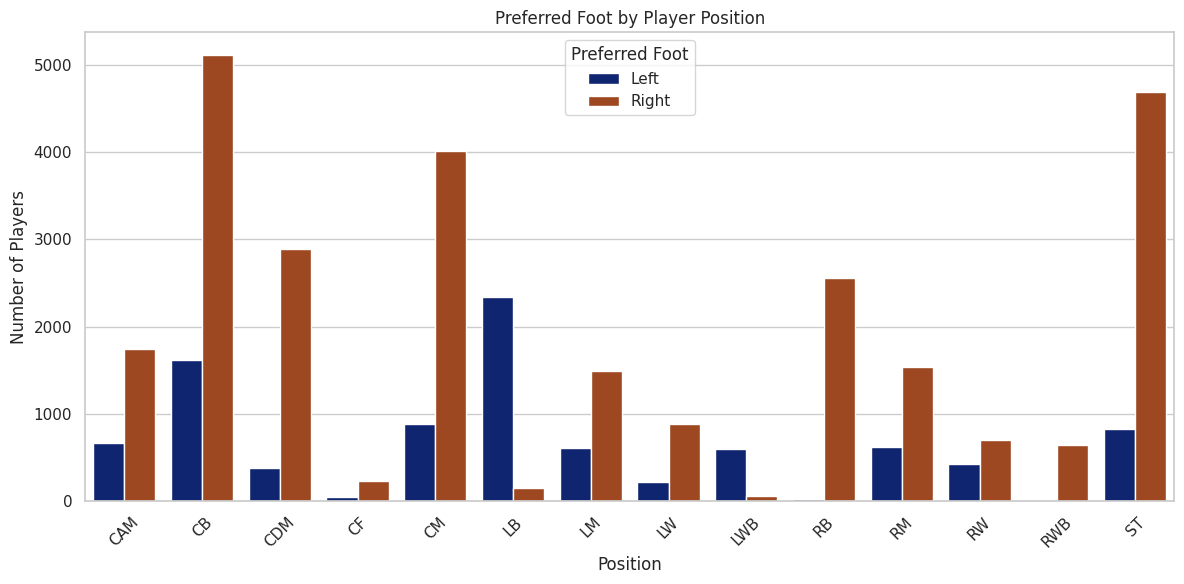

In [33]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="main_position",
    hue="preferred_foot"
)

plt.title("Preferred Foot by Player Position")
plt.xlabel("Position")
plt.ylabel("Number of Players")
plt.xticks(rotation=45)
plt.legend(title="Preferred Foot")

plt.tight_layout()
plt.show()

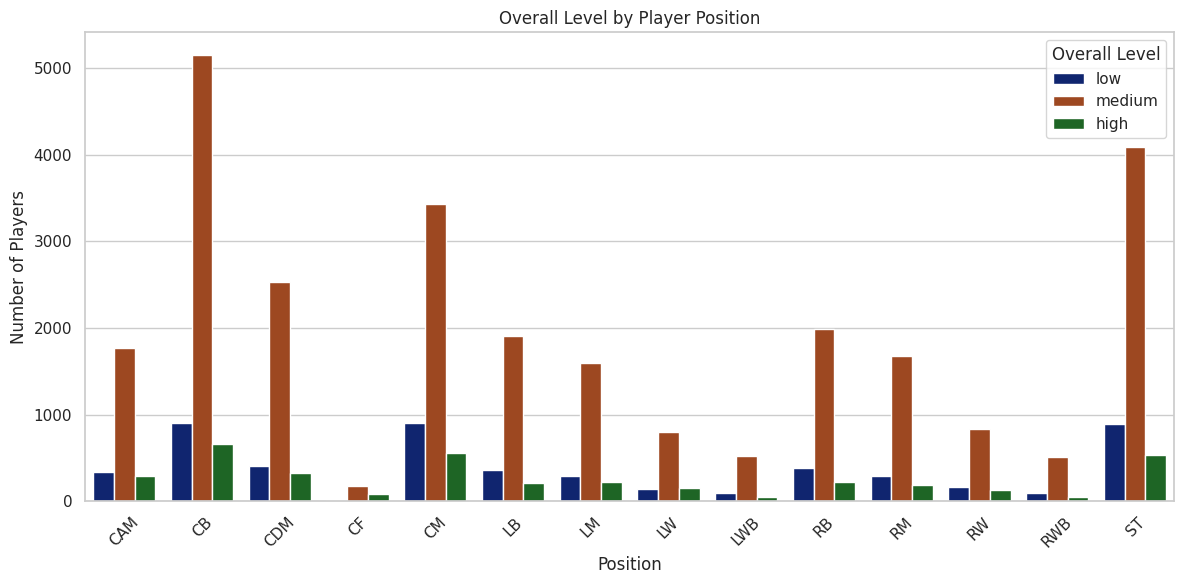

In [34]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="main_position",
    hue="overall_level"
)

plt.title("Overall Level by Player Position")
plt.xlabel("Position")
plt.ylabel("Number of Players")
plt.xticks(rotation=45)
plt.legend(title="Overall Level")

plt.tight_layout()
plt.show()

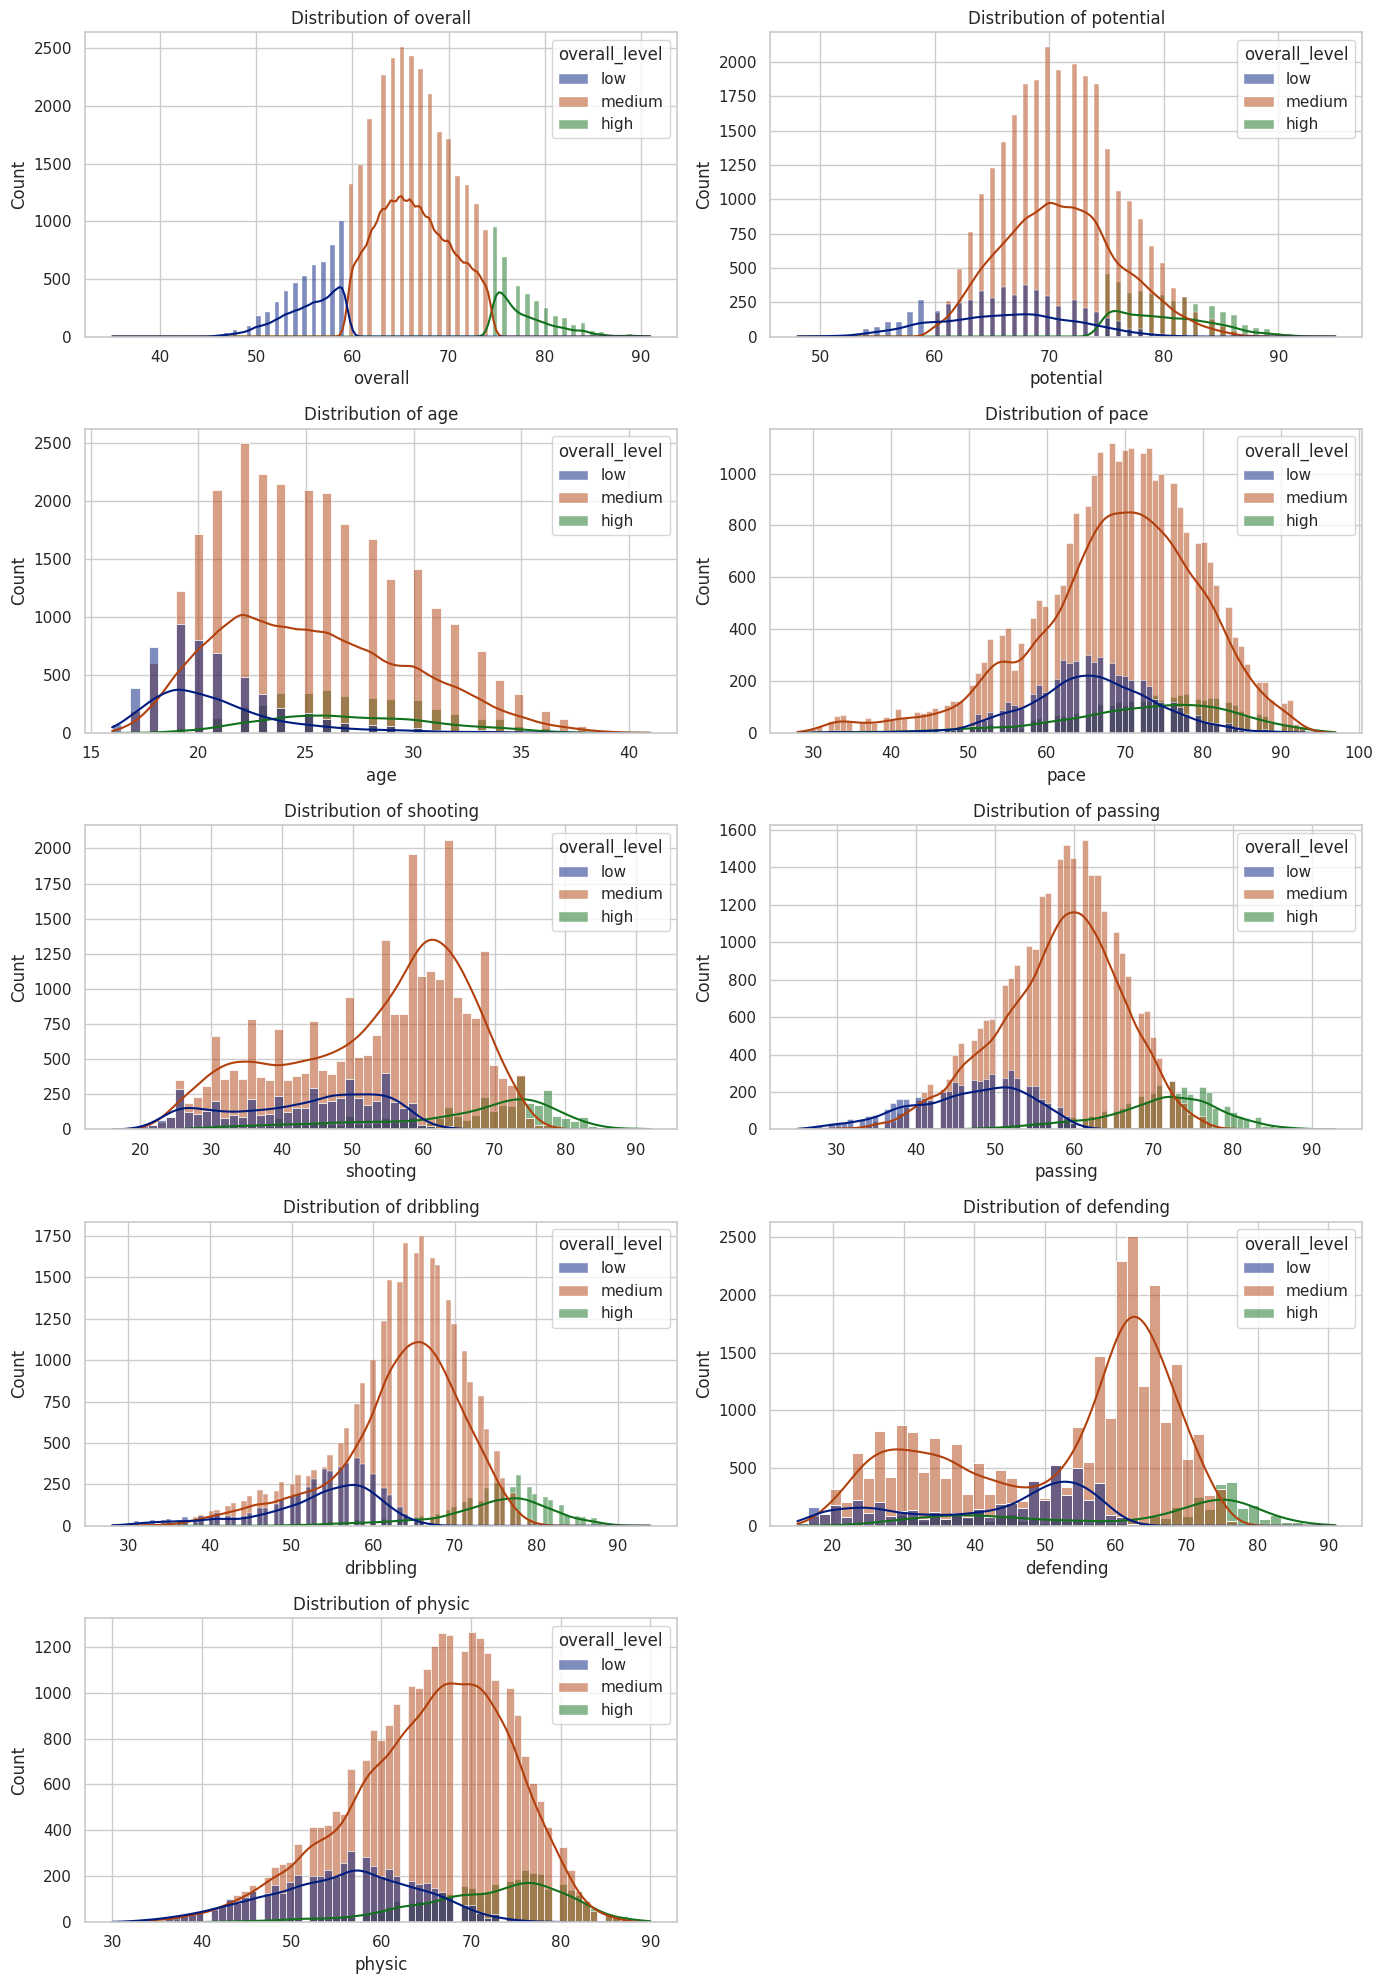

In [35]:
n_cols = 2
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, n_rows * 4)
)

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        data=df,
        x=col,
        hue="overall_level",
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(f"Distribution of {col}")

for i in range(len(num_cols), len(axes)):
    axes[i].remove()

plt.tight_layout()
plt.show()

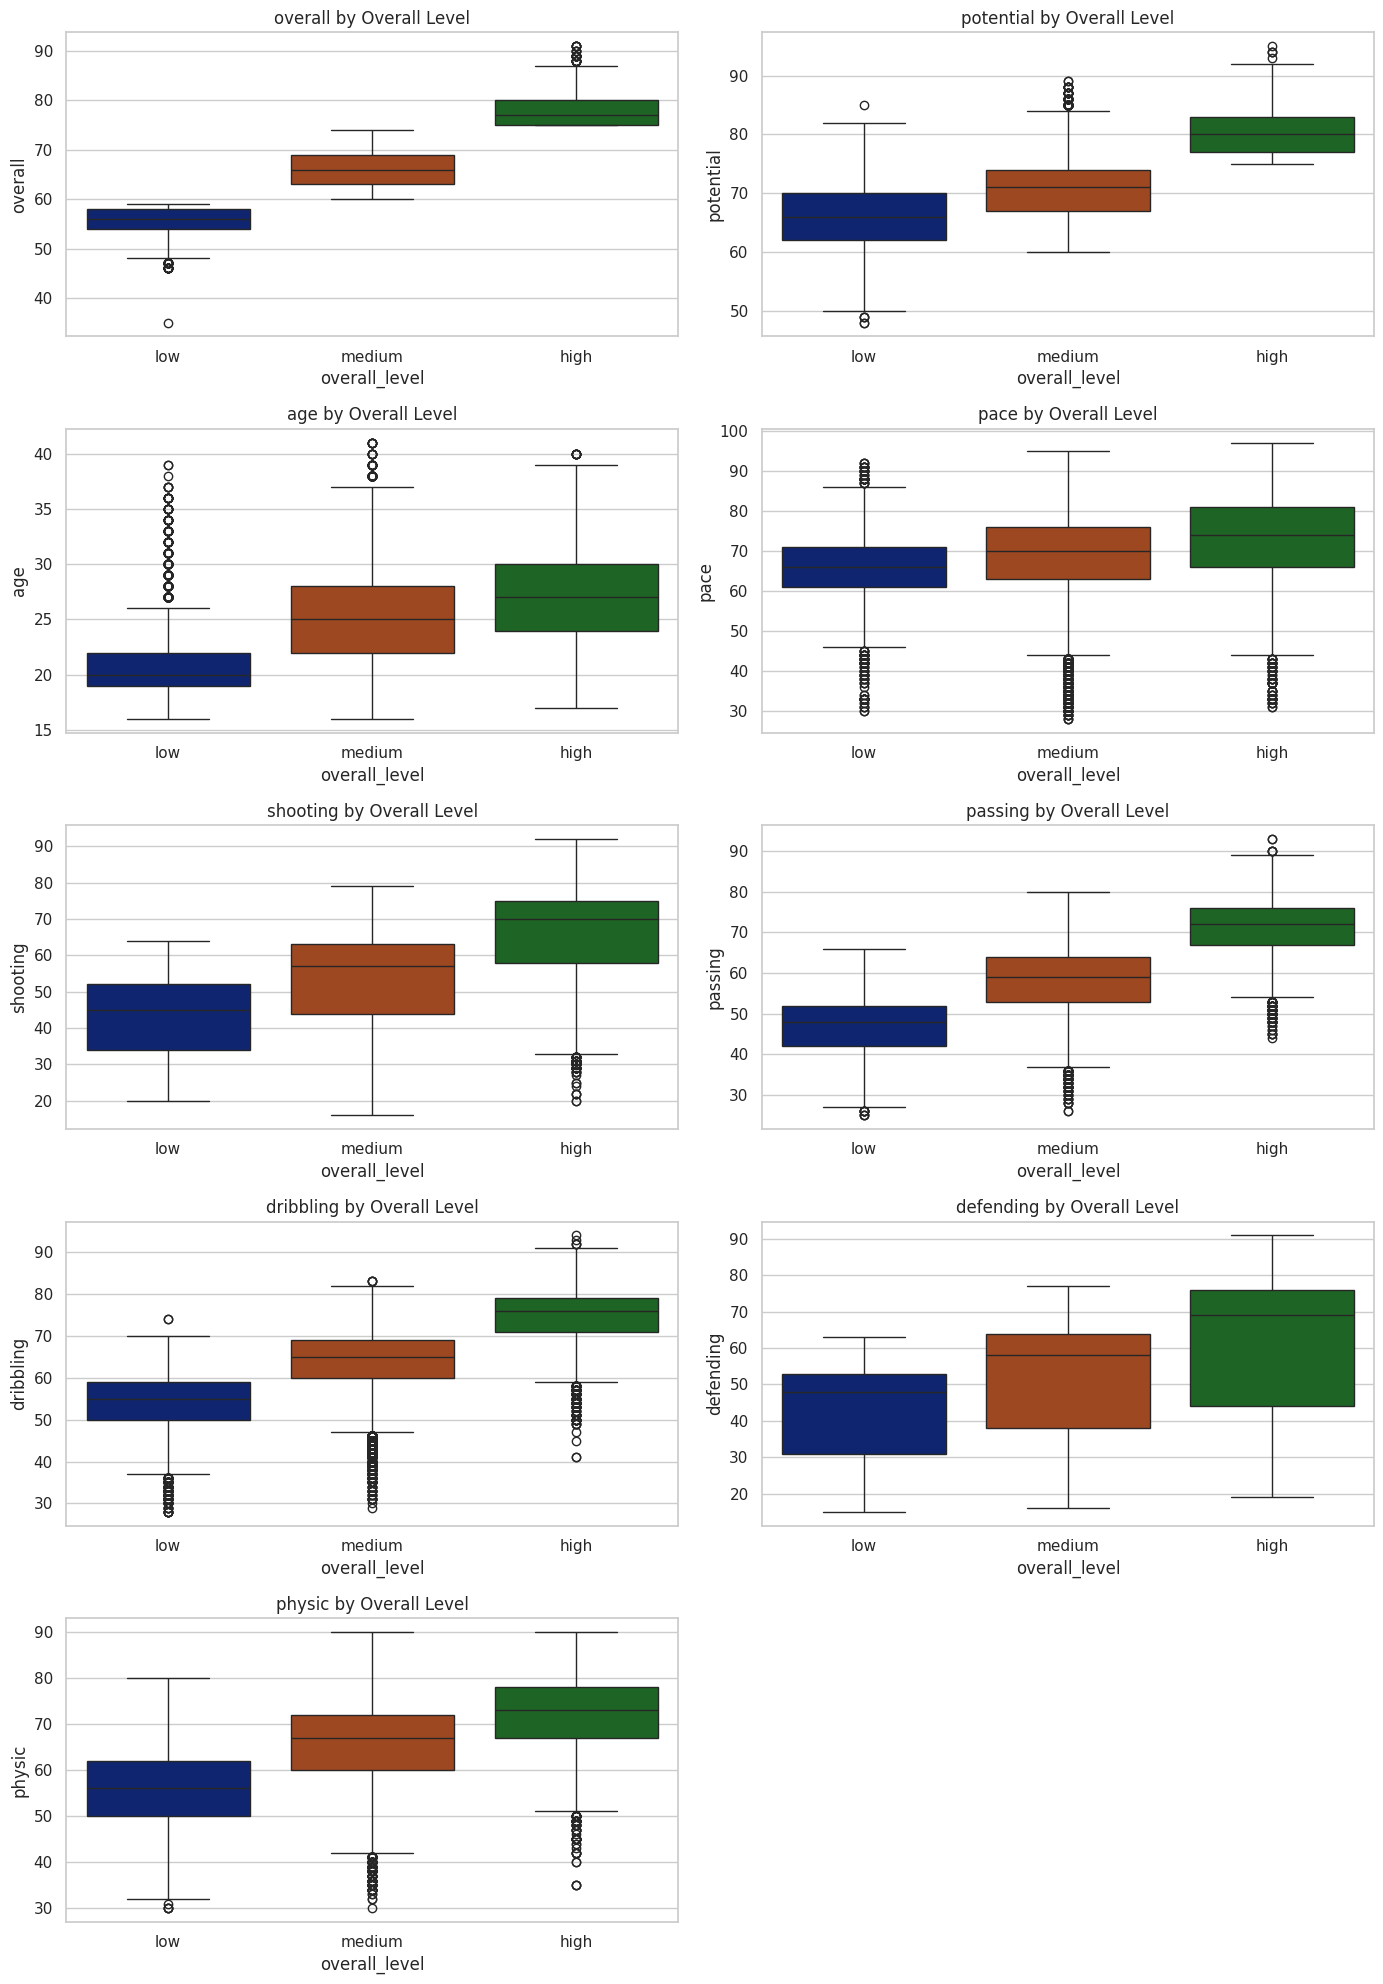

In [36]:
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, n_rows * 4)
)

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        data=df,
        x="overall_level",
        y=col,
        hue="overall_level",
        legend=False,
        ax=axes[i]
    )

    axes[i].set_title(f"{col} by Overall Level")

for i in range(len(num_cols), len(axes)):
    axes[i].remove()

plt.tight_layout()
plt.show()

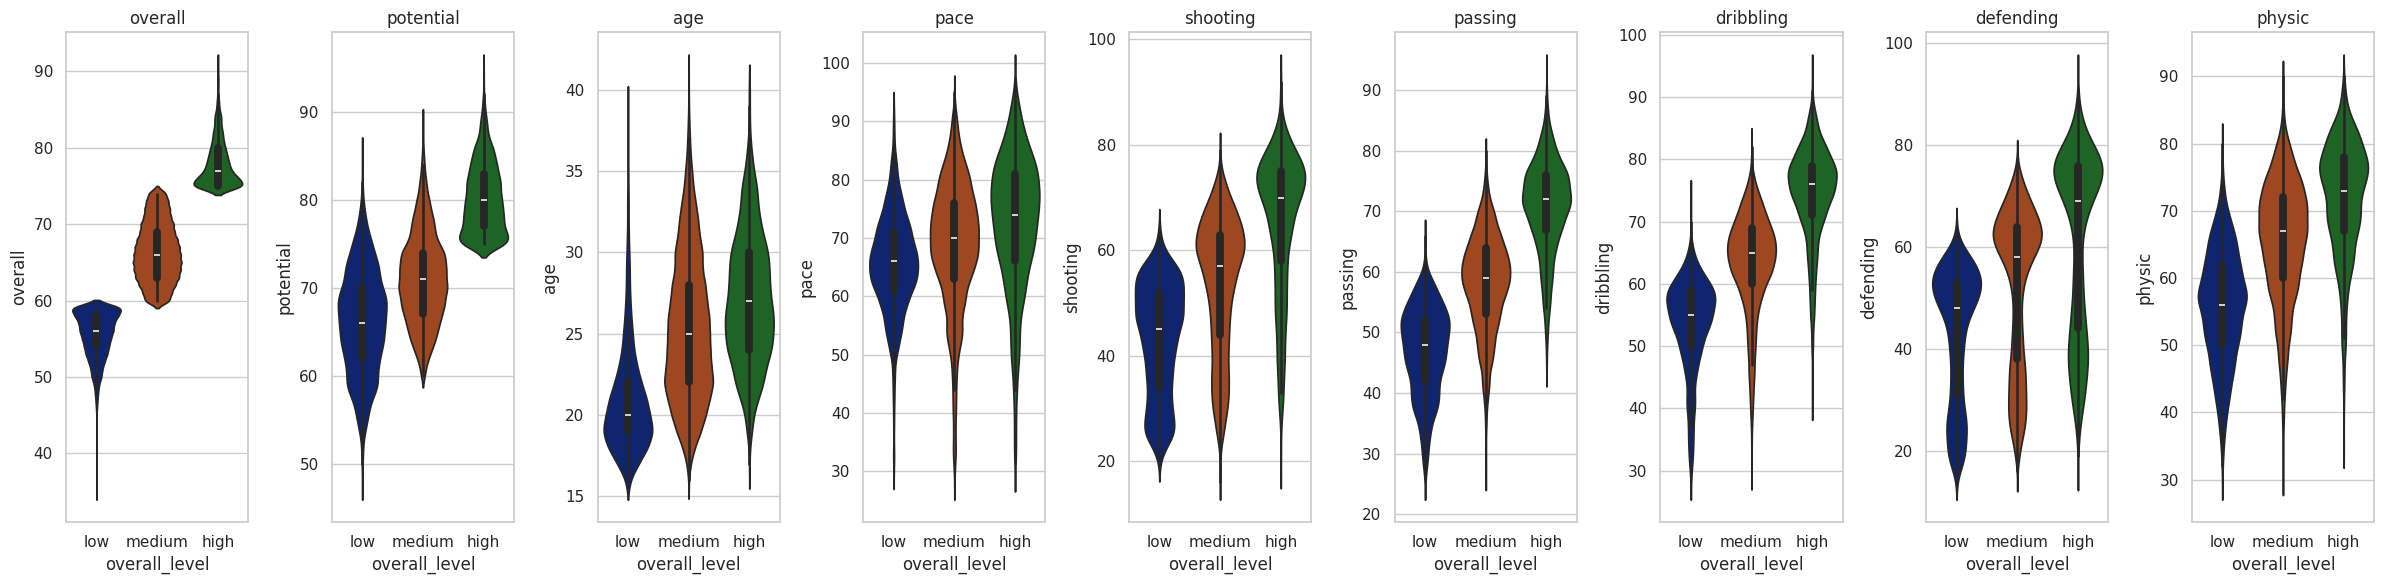

In [38]:
fig, axes = plt.subplots(
    1,
    len(num_cols),
    figsize=(24, 6)
)

for i, col in enumerate(num_cols):
    sns.violinplot(
        data=df,
        x="overall_level",
        y=col,
        hue="overall_level",
        legend=False,
        ax=axes[i]
    )

    axes[i].set_title(col)

plt.tight_layout()
plt.show()

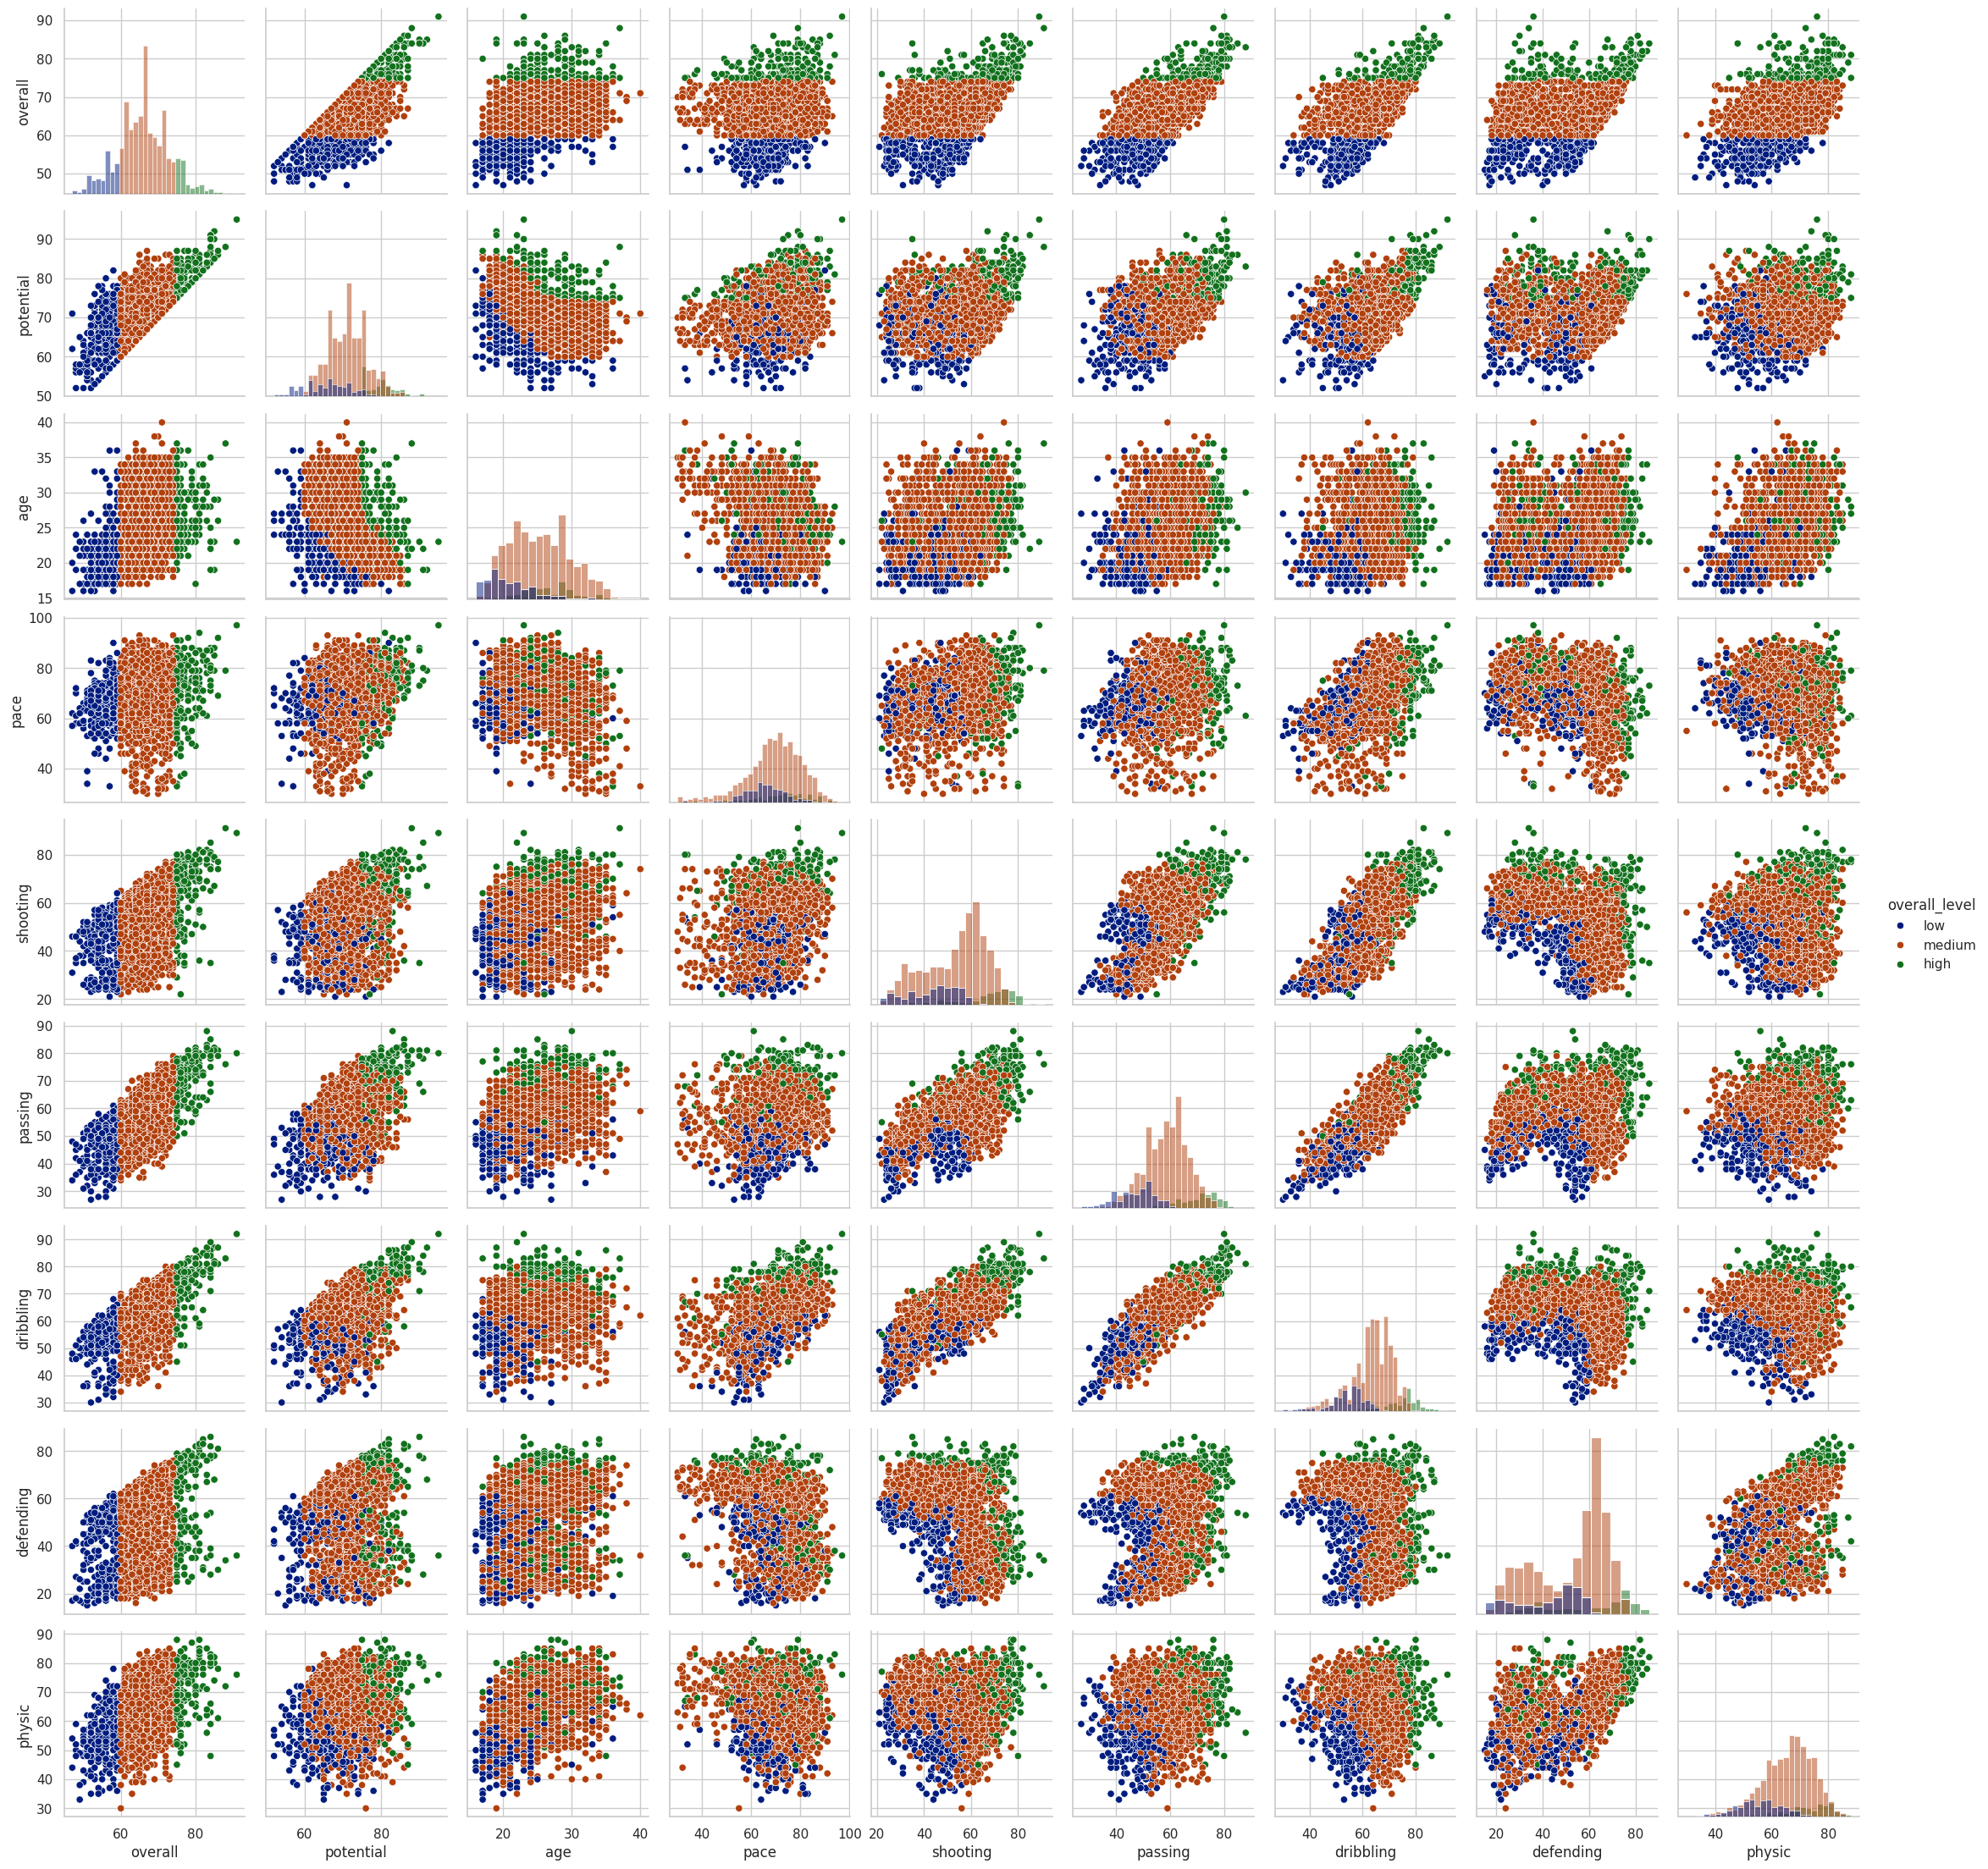

In [40]:
pairplot_df = df[num_cols + ["overall_level"]].sample(
    n=min(2000, len(df)),
    random_state=42
)

sns.pairplot(
    pairplot_df,
    vars=num_cols,
    hue="overall_level",
    diag_kind="hist"
)

plt.show()